# 🧠 Notebook 3 — CNN-BiLSTM Model Training
## Forensic Audio Authentication using Deep Learning

---

### 📋 Ce que fait ce notebook
1. Construit le Dataset PyTorch qui charge les `.npy` LFCC
2. Définit l'architecture complète **CNN → Bi-LSTM → Classifieur**
3. Gère le déséquilibre de classes avec WeightedRandomSampler
4. Entraîne le modèle pendant **20 epochs** avec Early Stopping
5. Trace les courbes de loss/accuracy en temps réel
6. Sauvegarde le meilleur checkpoint
7. Évalue sur le test set : **EER, FAR@1%FRR**, matrice de confusion
8. Export **ONNX** pour le déploiement

### ⏱️ Durée estimée : 1h30 – 2h GPU

### 📂 Inputs requis
```
/kaggle/input/forensic-lfcc-features/master_labels_with_features.csv
/kaggle/input/forensic-lfcc-features/lfcc_features/*.npy
```

### 📂 Outputs produits
```
/kaggle/working/checkpoints/best_model.pth    ← meilleur modèle
/kaggle/working/models/forensic_audio.onnx    ← modèle exporté
/kaggle/working/results/metrics.csv           ← EER, FAR, métriques
/kaggle/working/training_curves.png           ← courbes loss/accuracy
/kaggle/working/confusion_matrix.png          ← matrice de confusion
```

---
## CELLULE 1 — Vérification GPU + imports

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from sklearn.metrics import (
    roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')

# ── GPU ──────────────────────────────────────────────────────────────────────
print('=' * 60)
print('VÉRIFICATION ENVIRONNEMENT — NOTEBOOK 3')
print('=' * 60)
print(f'PyTorch  : {torch.__version__}')
print(f'GPU dispo : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM     : {mem_gb:.1f} GB')
    print('✅ GPU prêt')
else:
    device = torch.device('cpu')
    print('⚠️  CPU — entraînement sera lent (x10–x20)')

# ── Reproductibilité totale ───────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'\n✅ Seed fixé à {SEED} (résultats reproductibles)')
print(f'   Device : {device}')

VÉRIFICATION ENVIRONNEMENT — NOTEBOOK 3
PyTorch  : 2.10.0+cu128
GPU dispo : True
GPU      : Tesla T4
VRAM     : 15.6 GB
✅ GPU prêt

✅ Seed fixé à 42 (résultats reproductibles)
   Device : cuda


---
## CELLULE 2 — Hyperparamètres et chemins

In [2]:
# ── Paramètres LFCC (identiques aux notebooks précédents) ─────────────────────
N_LFCC    = 20
N_FRAMES  = 400

# ── Hyperparamètres du modèle ─────────────────────────────────────────────────
# CNN
CNN_CHANNELS    = [32, 64, 128]   # filtres dans chaque couche Conv2D
CNN_KERNEL      = 3               # taille du filtre 3×3
CNN_DROPOUT     = 0.2             # dropout après CNN

# Bi-LSTM
LSTM_HIDDEN     = 256             # unités cachées par direction
LSTM_LAYERS     = 2               # couches LSTM empilées
LSTM_DROPOUT    = 0.3             # dropout entre couches LSTM
# Sortie Bi-LSTM = LSTM_HIDDEN × 2 = 512 (car bidirectionnel)

# Classifieur
NUM_CLASSES     = 2               # 0=authentique, 1=manipulé

# ── Hyperparamètres d'entraînement ────────────────────────────────────────────
BATCH_SIZE      = 32              # clips par batch
LEARNING_RATE   = 1e-3            # taux d'apprentissage Adam
WEIGHT_DECAY    = 1e-4            # régularisation L2
N_EPOCHS        = 20              # epochs selon le cahier des charges
EARLY_STOPPING  = 5               # arrêt si val_loss ne s'améliore pas pendant 5 epochs
GRAD_CLIP       = 1.0             # gradient clipping — évite l'explosion des gradients

# ── Chemins ───────────────────────────────────────────────────────────────────
# ⚠️  Adapter selon le nom de ton dataset Kaggle
FEATURES_INPUT  = Path('/kaggle/input/datasets/elmiz20042004/output')
MASTER_CSV      = Path('/kaggle/input/datasets/elmiz20042004/output/master_labels_with_features.csv')
FEATURES_DIR    = Path('/kaggle/input/datasets/elmiz20042004/output/lfcc_features')

# Si tout est dans la même session :
# MASTER_CSV   = Path('/kaggle/working/master_labels_with_features.csv')
# FEATURES_DIR = Path('/kaggle/working/lfcc_features')

OUTPUT_DIR      = Path('/kaggle/working')
CKPT_DIR        = OUTPUT_DIR / 'checkpoints'
RESULTS_DIR     = OUTPUT_DIR / 'results'
MODELS_DIR      = OUTPUT_DIR / 'models'

for d in [CKPT_DIR, RESULTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CKPT_DIR  / 'best_model.pth'
ONNX_PATH       = MODELS_DIR / 'forensic_audio.onnx'

print('Hyperparamètres du modèle :')
print('=' * 50)
print(f'  Input shape     : (1, {N_LFCC}, {N_FRAMES})')
print(f'  CNN channels    : {CNN_CHANNELS}')
print(f'  LSTM hidden     : {LSTM_HIDDEN} × 2 directions = {LSTM_HIDDEN*2}')
print(f'  LSTM layers     : {LSTM_LAYERS}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Learning rate   : {LEARNING_RATE}')
print(f'  Epochs          : {N_EPOCHS}')
print(f'  Early stopping  : {EARLY_STOPPING} epochs patience')
print('=' * 50)

Hyperparamètres du modèle :
  Input shape     : (1, 20, 400)
  CNN channels    : [32, 64, 128]
  LSTM hidden     : 256 × 2 directions = 512
  LSTM layers     : 2
  Batch size      : 32
  Learning rate   : 0.001
  Epochs          : 20
  Early stopping  : 5 epochs patience


---
## CELLULE 3 — Dataset PyTorch

> Le Dataset charge les `.npy` depuis le disque.  
> C'est **50× plus rapide** que recalculer les LFCC à chaque epoch.

In [3]:
class ForensicAudioDataset(Dataset):
    """
    Dataset PyTorch pour la détection de manipulation audio.
    
    Charge les features LFCC pré-calculées (.npy) depuis le disque.
    Chaque sample retourne :
        - lfcc  : Tensor (1, 20, 400) float32  ← entrée du CNN
        - label : Tensor int64                  ← 0=authentique, 1=manipulé
    
    La dimension supplémentaire '1' est le canal — le CNN traite
    la matrice LFCC comme une image en niveaux de gris (1 canal).
    """
    
    def __init__(self, df, features_dir=None, augment=False):
        """
        Args:
            df           : DataFrame avec colonnes 'feature_path' et 'label'
            features_dir : dossier alternatif pour les .npy (optionnel)
            augment      : appliquer data augmentation (train seulement)
        """
        self.df           = df.reset_index(drop=True)
        self.features_dir = Path(features_dir) if features_dir else None
        self.augment      = augment
        
        # Pré-vérification : compter les fichiers manquants
        missing = 0
        for _, row in self.df.iterrows():
            path = self._get_path(row['feature_path'])
            if not Path(path).exists():
                missing += 1
        
        if missing > 0:
            print(f'⚠️  {missing}/{len(self.df)} fichiers .npy manquants')
    
    def _get_path(self, feature_path):
        """Résout le chemin du .npy — utilise features_dir si défini."""
        if self.features_dir:
            # Utiliser le nom de fichier seulement, dans le nouveau dossier
            return self.features_dir / Path(feature_path).name
        return Path(feature_path)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = self._get_path(row['feature_path'])
        
        try:
            # Charger la matrice LFCC (20, 400)
            lfcc = np.load(str(path)).astype(np.float32)
        except Exception:
            # Si fichier corrompu → retourner des zéros (ne bloque pas l'entraînement)
            lfcc = np.zeros((N_LFCC, N_FRAMES), dtype=np.float32)
        
        # Convertir en Tensor et ajouter dimension canal
        # (20, 400) → (1, 20, 400) — le CNN attend (batch, canaux, hauteur, largeur)
        lfcc_tensor = torch.tensor(lfcc).unsqueeze(0)  # (1, 20, 400)
        label       = torch.tensor(int(row['label']), dtype=torch.long)
        
        # Data augmentation (train seulement)
        if self.augment:
            lfcc_tensor = self._augment(lfcc_tensor)
        
        return lfcc_tensor, label
    
    def _augment(self, lfcc):
        """
        Augmentations légères pour améliorer la généralisation.
        Appliquées aléatoirement pendant l'entraînement seulement.
        """
        # Bruit gaussien léger (simule variations de microphone)
        if torch.rand(1).item() < 0.3:
            noise = torch.randn_like(lfcc) * 0.02
            lfcc = lfcc + noise
        
        # Masquage temporel (SpecAugment simplifié)
        # Cache aléatoirement 10-30 frames consécutives
        if torch.rand(1).item() < 0.3:
            t_start = torch.randint(0, N_FRAMES - 30, (1,)).item()
            t_width = torch.randint(10, 30, (1,)).item()
            lfcc[:, :, t_start:t_start + t_width] = 0
        
        # Masquage fréquentiel
        # Cache aléatoirement 2-5 coefficients LFCC consécutifs
        if torch.rand(1).item() < 0.3:
            f_start = torch.randint(0, N_LFCC - 5, (1,)).item()
            f_width = torch.randint(2, 5, (1,)).item()
            lfcc[:, f_start:f_start + f_width, :] = 0
        
        return lfcc


print('✅ ForensicAudioDataset défini')
print('   __getitem__ retourne : (lfcc: Tensor(1,20,400), label: Tensor int64)')
print('   Augmentations : bruit gaussien + masquage temporel + masquage fréquentiel')

✅ ForensicAudioDataset défini
   __getitem__ retourne : (lfcc: Tensor(1,20,400), label: Tensor int64)
   Augmentations : bruit gaussien + masquage temporel + masquage fréquentiel


---
## CELLULE 4 — Chargement des données et DataLoaders

In [4]:
# ── Chargement du CSV ─────────────────────────────────────────────────────────
if not MASTER_CSV.exists():
    # Recherche automatique
    for root, dirs, files in os.walk('/kaggle'):
        for f in files:
            if f == 'master_labels_with_features.csv':
                MASTER_CSV = Path(os.path.join(root, f))
                print(f'✅ CSV trouvé : {MASTER_CSV}')
                break

df = pd.read_csv(MASTER_CSV)
print(f'✅ CSV chargé : {len(df):,} clips')

# ── Splits ────────────────────────────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'  ].reset_index(drop=True)
test_df  = df[df['split'] == 'test' ].reset_index(drop=True)

print(f'\n   Train : {len(train_df):,} clips')
print(f'   Val   : {len(val_df):,} clips')
print(f'   Test  : {len(test_df):,} clips')

# ── WeightedRandomSampler — gestion du déséquilibre de classes ───────────────
# Pourquoi ? ASVspoof a ratio 1:9 (authentique:fake)
# Sans pondération, le modèle apprend à toujours dire 'fake' → EER catastrophique
n_authentic = (train_df['label'] == 0).sum()
n_fake      = (train_df['label'] == 1).sum()

print(f'\n   Train — Authentique : {n_authentic:,}')
print(f'   Train — Manipulé   : {n_fake:,}')
print(f'   Ratio              : 1:{n_fake/max(n_authentic,1):.1f}')

# Poids inversement proportionnels à la fréquence
weight_authentic = 1.0 / n_authentic
weight_fake      = 1.0 / n_fake
sample_weights   = [
    weight_authentic if label == 0 else weight_fake
    for label in train_df['label']
]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

# ── Création des datasets ─────────────────────────────────────────────────────
train_dataset = ForensicAudioDataset(train_df, FEATURES_DIR, augment=True)
val_dataset   = ForensicAudioDataset(val_df,   FEATURES_DIR, augment=False)
test_dataset  = ForensicAudioDataset(test_df,  FEATURES_DIR, augment=False)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,     # WeightedRandomSampler remplace shuffle=True
    num_workers = 2,
    pin_memory  = True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True if torch.cuda.is_available() else False
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2
)

# ── Test d'un batch ───────────────────────────────────────────────────────────
batch_lfcc, batch_labels = next(iter(train_loader))
print(f'\n✅ DataLoaders créés')
print(f'   Batch LFCC shape : {batch_lfcc.shape}')
print(f'   Batch labels     : {batch_labels.shape} — valeurs: {batch_labels.unique().tolist()}')
print(f'   Batches/epoch    : {len(train_loader)}')

✅ CSV chargé : 138,928 clips

   Train : 39,339 clips
   Val   : 26,589 clips
   Test  : 73,000 clips

   Train — Authentique : 4,991
   Train — Manipulé   : 34,348
   Ratio              : 1:6.9

✅ DataLoaders créés
   Batch LFCC shape : torch.Size([32, 1, 20, 400])
   Batch labels     : torch.Size([32]) — valeurs: [0, 1]
   Batches/epoch    : 1230


---
## CELLULE 5 — Architecture CNN-BiLSTM

> C'est le coeur du projet.  

```
Input (batch, 1, 20, 400)    ← matrice LFCC vue comme image 1 canal
       ↓
  ┌─────────────────────────────┐
  │  CNN BLOCK                  │
  │  Conv2D(1→32)  + BN + ReLU  │  détecte patterns locaux
  │  MaxPool(2×2)               │  réduit : (32, 10, 200)
  │  Conv2D(32→64) + BN + ReLU  │  patterns plus complexes
  │  MaxPool(2×2)               │  réduit : (64, 5, 100)
  │  Conv2D(64→128)+ BN + ReLU  │  signatures de manipulation
  │  Dropout(0.2)               │  (128, 5, 100)
  └─────────────────────────────┘
       ↓ reshape pour LSTM
  (batch, 100, 128×5=640)      ← 100 frames, 640 features par frame
       ↓
  ┌─────────────────────────────┐
  │  Bi-LSTM BLOCK              │
  │  LSTM(640→256, 2 layers)    │  cohérence temporelle →
  │  bidirectional=True         │  cohérence temporelle ←
  │  Dropout(0.3)               │  sortie: (batch, 100, 512)
  └─────────────────────────────┘
       ↓ prendre le dernier état caché
  (batch, 512)                 ← représentation globale du clip
       ↓
  ┌─────────────────────────────┐
  │  CLASSIFIEUR                │
  │  Linear(512→128) + ReLU    │
  │  Dropout(0.3)               │
  │  Linear(128→2)              │
  └─────────────────────────────┘
       ↓
  Output (batch, 2)            ← [score_authentique, score_manipulé]
```

In [5]:
class CNNBiLSTM(nn.Module):
    """
    Modèle CNN-BiLSTM pour la détection de manipulation audio forensique.
    
    Architecture :
    - CNN : 3 couches Conv2D pour détecter les anomalies spectrales
    - Bi-LSTM : 2 couches bidirectionnelles pour la cohérence temporelle
    - Classifieur : 2 couches Linear pour la décision finale
    
    Input  : (batch, 1, 20, 400)  — matrice LFCC
    Output : (batch, 2)           — logits [authentique, manipulé]
    """
    
    def __init__(self,
                 n_lfcc=N_LFCC,
                 n_frames=N_FRAMES,
                 cnn_channels=CNN_CHANNELS,
                 lstm_hidden=LSTM_HIDDEN,
                 lstm_layers=LSTM_LAYERS,
                 lstm_dropout=LSTM_DROPOUT,
                 cnn_dropout=CNN_DROPOUT,
                 num_classes=NUM_CLASSES):
        super(CNNBiLSTM, self).__init__()
        
        self.n_lfcc   = n_lfcc
        self.n_frames = n_frames
        
        # ── BLOC CNN ────────────────────────────────────────────────────────
        # Traite la matrice LFCC (20×400) comme une image 2D
        # Chaque filtre 3×3 glisse sur la matrice et détecte des patterns locaux
        
        self.cnn = nn.Sequential(
            # Couche 1 : détecte edges et transitions abruptes
            nn.Conv2d(1, cnn_channels[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[0]),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Après pool : (batch, 32, 10, 200)
            
            # Couche 2 : patterns spectraux complexes (artefacts vocoder)
            nn.Conv2d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[1]),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Après pool : (batch, 64, 5, 100)
            
            # Couche 3 : signatures de manipulation — combinaisons de patterns
            nn.Conv2d(cnn_channels[1], cnn_channels[2], kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels[2]),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=cnn_dropout),
            # Sortie : (batch, 128, 5, 100)
        )
        
        # Calculer la taille de sortie du CNN dynamiquement
        # Pour éviter les erreurs de shape si les paramètres changent
        self._cnn_output_size = self._get_cnn_output_size(n_lfcc, n_frames)
        
        # ── BLOC Bi-LSTM ─────────────────────────────────────────────────────
        # Reçoit la sortie CNN reformatée en séquence temporelle
        # input_size = nombre de features par frame (après CNN)
        # hidden_size = 256 unités par direction
        # bidirectional=True → lit la séquence dans les 2 sens
        # Sortie finale = 256×2 = 512 (concaténation des 2 directions)
        
        self.bilstm = nn.LSTM(
            input_size   = self._cnn_output_size,
            hidden_size  = lstm_hidden,
            num_layers   = lstm_layers,
            batch_first  = True,           # (batch, seq, features)
            bidirectional= True,           # ← cœur du Bi-LSTM
            dropout      = lstm_dropout if lstm_layers > 1 else 0
        )
        
        # Taille de sortie Bi-LSTM = hidden_size × 2
        lstm_out_size = lstm_hidden * 2  # = 512
        
        # ── CLASSIFIEUR ──────────────────────────────────────────────────────
        # Réduit progressivement de 512 → 128 → 2
        # Produit les logits pour softmax
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )
        
        # Initialisation des poids (He initialization pour ReLU)
        self._init_weights()
    
    def _get_cnn_output_size(self, n_lfcc, n_frames):
        """
        Calcule dynamiquement la taille de sortie du CNN par frame temporelle.
        Passe un tensor fictif dans le CNN pour obtenir la shape réelle.
        """
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_lfcc, n_frames)
            out   = self.cnn(dummy)       # (1, 128, h, w)
            # Reformater : (1, 128, h, w) → (1, w, 128×h)
            b, c, h, w = out.shape
            return c * h  # features par frame temporelle
    
    def _init_weights(self):
        """Initialisation He pour Conv2d, Xavier pour Linear."""
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out',
                                         nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
    
    def forward(self, x):
        """
        Forward pass complet : LFCC → CNN → Bi-LSTM → Classifieur → logits
        
        Args:
            x : Tensor (batch, 1, 20, 400)
        Returns:
            logits : Tensor (batch, 2)
        """
        batch_size = x.shape[0]
        
        # ── ÉTAPE 1 : CNN ────────────────────────────────────────────────────
        # (batch, 1, 20, 400) → (batch, 128, 5, 100)
        cnn_out = self.cnn(x)
        
        # ── ÉTAPE 2 : Reformater pour Bi-LSTM ───────────────────────────────
        # Le LSTM attend une séquence : (batch, seq_len, features)
        # On prend l'axe temporel (w=100) comme séquence
        # et on aplatit les dimensions (canaux × hauteur) comme features
        b, c, h, w = cnn_out.shape
        # (batch, 128, 5, 100) → (batch, 100, 128×5=640)
        lstm_in = cnn_out.permute(0, 3, 1, 2)          # (batch, 100, 128, 5)
        lstm_in = lstm_in.contiguous().view(b, w, c*h)  # (batch, 100, 640)
        
        # ── ÉTAPE 3 : Bi-LSTM ────────────────────────────────────────────────
        # Lit la séquence dans les 2 sens et concatène
        # lstm_out : (batch, 100, 512) — sortie à chaque step
        # h_n      : (4, batch, 256)  — états cachés finaux (2 layers × 2 directions)
        lstm_out, (h_n, c_n) = self.bilstm(lstm_in)
        
        # Prendre le dernier état caché de la dernière couche (forward + backward)
        # h_n[-2] = forward direction, dernière couche
        # h_n[-1] = backward direction, dernière couche
        h_forward  = h_n[-2]  # (batch, 256)
        h_backward = h_n[-1]  # (batch, 256)
        lstm_feat  = torch.cat([h_forward, h_backward], dim=1)  # (batch, 512)
        
        # ── ÉTAPE 4 : Classifieur ────────────────────────────────────────────
        # (batch, 512) → (batch, 2)
        logits = self.classifier(lstm_feat)
        
        return logits


# ── Instancier le modèle ──────────────────────────────────────────────────────
model = CNNBiLSTM().to(device)

# Compter les paramètres
total_params    = sum(p.numel() for p in model.parameters())
trainable_params= sum(p.numel() for p in model.parameters() if p.requires_grad)

print('✅ Modèle CNN-BiLSTM créé')
print(f'   Paramètres totaux      : {total_params:,}')
print(f'   Paramètres entraînables: {trainable_params:,}')
print(f'   Taille CNN output/frame: {model._cnn_output_size}')

# Test du forward pass avec un batch factice
with torch.no_grad():
    dummy_input  = torch.zeros(BATCH_SIZE, 1, N_LFCC, N_FRAMES).to(device)
    dummy_output = model(dummy_input)

print(f'\n   Test forward pass :')
print(f'   Input  : {dummy_input.shape}')
print(f'   Output : {dummy_output.shape}  ← doit être ({BATCH_SIZE}, 2)')
assert dummy_output.shape == (BATCH_SIZE, NUM_CLASSES), 'Shape incorrecte !'
print(f'   ✅ Forward pass OK')

✅ Modèle CNN-BiLSTM créé
   Paramètres totaux      : 3,575,106
   Paramètres entraînables: 3,575,106
   Taille CNN output/frame: 640

   Test forward pass :
   Input  : torch.Size([32, 1, 20, 400])
   Output : torch.Size([32, 2])  ← doit être (32, 2)
   ✅ Forward pass OK


---
## CELLULE 6 — Loss, Optimizer et Scheduler

In [6]:
# ── Loss avec pondération des classes ────────────────────────────────────────
n_total     = n_authentic + n_fake
w_authentic = n_total / (2.0 * n_authentic)
w_fake      = n_total / (2.0 * n_fake)

class_weights = torch.tensor([w_authentic, w_fake],
                               dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f'Loss : CrossEntropyLoss pondérée')
print(f'   Poids authentique (0) : {w_authentic:.3f}')
print(f'   Poids manipulé   (1) : {w_fake:.3f}')

# ── Optimizer Adam ────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# ── Learning Rate Scheduler ───────────────────────────────────────────────────
# verbose=True supprimé — n'existe plus dans PyTorch 2.x
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 3,
    # verbose = True  ← SUPPRIMÉ (PyTorch 2.x)
)

# Afficher manuellement le LR à chaque epoch dans la boucle d'entraînement
print(f'Optimizer : Adam')
print(f'   lr           = {LEARNING_RATE}')
print(f'   weight_decay = {WEIGHT_DECAY}')
print(f'\nScheduler : ReduceLROnPlateau')
print(f'   factor   = 0.5 (LR ÷ 2)')
print(f'   patience = 3 epochs')
print(f'\n✅ Tout prêt pour l\'entraînement')

Loss : CrossEntropyLoss pondérée
   Poids authentique (0) : 3.941
   Poids manipulé   (1) : 0.573
Optimizer : Adam
   lr           = 0.001
   weight_decay = 0.0001

Scheduler : ReduceLROnPlateau
   factor   = 0.5 (LR ÷ 2)
   patience = 3 epochs

✅ Tout prêt pour l'entraînement


---
## CELLULE 7 — Boucle d'entraînement

> C'est la cellule la plus longue (~1h30 sur GPU T4).  
> Elle affiche la loss et l'accuracy après chaque epoch.  
> Elle sauvegarde automatiquement le meilleur modèle.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip=GRAD_CLIP):
    """
    Entraîne le modèle sur un epoch complet.
    Retourne : loss moyenne, accuracy
    """
    model.train()  # active dropout et batchnorm en mode train
    total_loss = 0.0
    correct    = 0
    total      = 0
    
    for lfcc, labels in loader:
        lfcc   = lfcc.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()          # réinitialiser les gradients
        logits = model(lfcc)           # (batch, 2)
        loss   = criterion(logits, labels)
        
        # Backward pass
        loss.backward()                # calculer les gradients
        
        # Gradient clipping — évite l'explosion des gradients dans le LSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        
        optimizer.step()               # mettre à jour les poids
        
        # Statistiques
        total_loss += loss.item() * lfcc.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += lfcc.size(0)
    
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Évalue le modèle sur un loader (val ou test).
    Retourne : loss, accuracy, toutes les probabilités et labels vrais
    """
    model.eval()  # désactive dropout et batchnorm
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_probs  = []
    all_labels = []
    
    for lfcc, labels in loader:
        lfcc   = lfcc.to(device)
        labels = labels.to(device)
        
        logits = model(lfcc)
        loss   = criterion(logits, labels)
        
        probs = F.softmax(logits, dim=1)[:, 1]  # probabilité classe 'manipulé'
        preds = logits.argmax(dim=1)
        
        total_loss += loss.item() * lfcc.size(0)
        correct    += (preds == labels).sum().item()
        total      += lfcc.size(0)
        all_probs .extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    return (total_loss / total, correct / total,
            np.array(all_probs), np.array(all_labels))


# ── Boucle d'entraînement principale ─────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'lr'        : []
}

best_val_loss     = float('inf')
patience_counter  = 0
best_epoch        = 0

print('🚀 Démarrage de l\'entraînement')
print(f'   {N_EPOCHS} epochs × {len(train_loader)} batches = {N_EPOCHS * len(train_loader)} steps')
print('=' * 65)
print(f'{"Epoch":>6} {"Train Loss":>11} {"Val Loss":>10} '
      f'{"Train Acc":>10} {"Val Acc":>9} {"LR":>10} {"Status":>8}')
print('=' * 65)

t_total = time.time()

for epoch in range(1, N_EPOCHS + 1):
    t_epoch = time.time()
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validation
    val_loss, val_acc, val_probs, val_true = evaluate(
        model, val_loader, criterion, device
    )
    
    # Scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    
    # Sauvegarder l'historique
    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)
    history['lr'        ].append(current_lr)
    
    # Sauvegarder le meilleur modèle
    status = ''
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_epoch       = epoch
        patience_counter = 0
        status = '✅ BEST'
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss'       : val_loss,
            'val_acc'        : val_acc,
            'history'        : history,
            'hyperparams'    : {
                'n_lfcc'      : N_LFCC,
                'n_frames'    : N_FRAMES,
                'lstm_hidden' : LSTM_HIDDEN,
                'lstm_layers' : LSTM_LAYERS,
                'batch_size'  : BATCH_SIZE,
            }
        }, BEST_MODEL_PATH)
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING:
            status = '🛑 STOP'
    
    elapsed = time.time() - t_epoch
    print(f'{epoch:>6} {train_loss:>11.4f} {val_loss:>10.4f} '
          f'{train_acc:>9.1%} {val_acc:>8.1%} {current_lr:>10.2e} {status:>8}  '
          f'({elapsed:.0f}s)')
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING:
        print(f'\n⏹  Early stopping déclenché après {epoch} epochs')
        print(f'   Meilleur modèle : epoch {best_epoch} (val_loss={best_val_loss:.4f})')
        break

total_time = time.time() - t_total
print('=' * 65)
print(f'\n✅ Entraînement terminé en {total_time/60:.1f} minutes')
print(f'   Meilleur epoch   : {best_epoch}')
print(f'   Meilleure val_loss : {best_val_loss:.4f}')
print(f'   Modèle sauvé     : {BEST_MODEL_PATH}')

🚀 Démarrage de l'entraînement
   20 epochs × 1230 batches = 24600 steps
 Epoch  Train Loss   Val Loss  Train Acc   Val Acc         LR   Status
     1      0.1894     0.2241     81.5%    87.9%   1.00e-03   ✅ BEST  (263s)
     2      0.1163     0.0657     89.9%    98.1%   1.00e-03   ✅ BEST  (102s)
     3      0.1044     0.1189     92.4%    93.4%   1.00e-03           (72s)
     4      0.0828     0.0714     93.1%    97.7%   1.00e-03           (70s)
     5      0.0797     0.0639     93.3%    96.2%   1.00e-03   ✅ BEST  (70s)
     6      0.0782     0.0534     93.6%    98.1%   1.00e-03   ✅ BEST  (69s)
     7      0.0691     0.0843     94.2%    95.0%   1.00e-03           (70s)
     8      0.0699     0.0479     94.1%    97.8%   1.00e-03   ✅ BEST  (70s)
     9      0.0675     0.0681     94.5%    97.3%   1.00e-03           (70s)
    10      0.0638     0.0616     94.8%    97.2%   1.00e-03           (70s)
    11      0.0621     0.0498     95.2%    97.9%   1.00e-03           (68s)
    12      0.0600 

---
## CELLULE 8 — Courbes d'entraînement

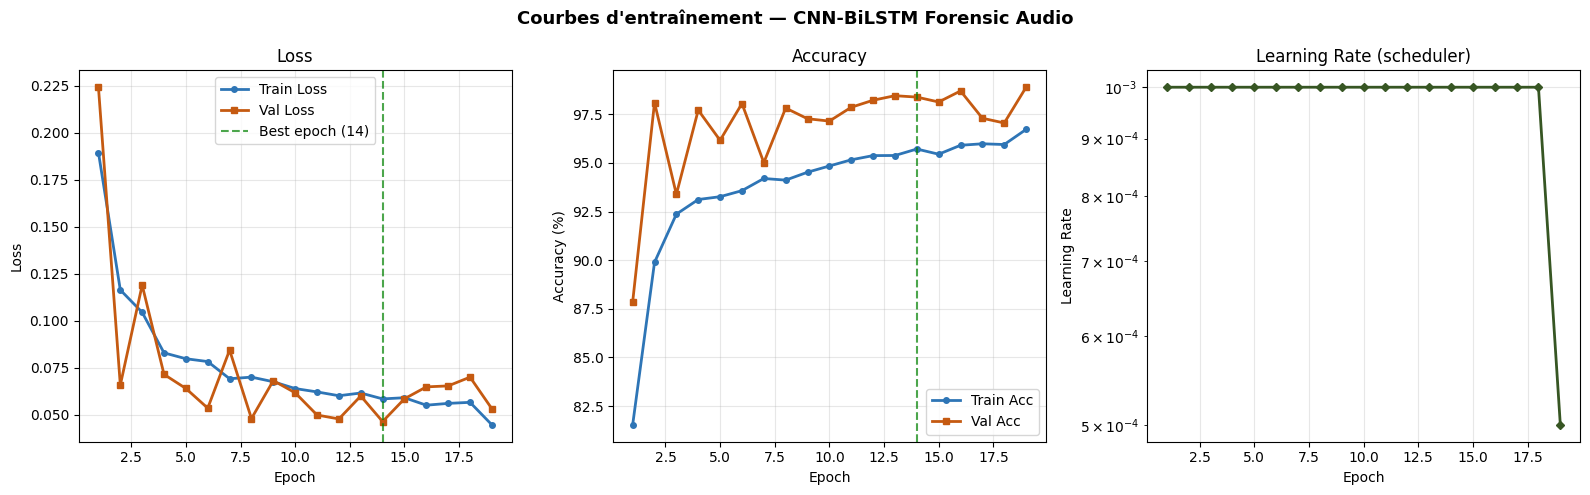


📊 Analyse des courbes :
   Train loss finale : 0.0446
   Val   loss finale : 0.0531
   Écart val-train   : 0.0085
   ✅ Bonne généralisation


In [8]:
# ── Visualisation des courbes loss et accuracy ────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Courbes d\'entraînement — CNN-BiLSTM Forensic Audio',
             fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'o-',
             color='#2E75B6', label='Train Loss', linewidth=2, markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   's-',
             color='#C55A11', label='Val Loss',   linewidth=2, markersize=4)
axes[0].axvline(x=best_epoch, color='green', linestyle='--',
                alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'o-',
             color='#2E75B6', label='Train Acc', linewidth=2, markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   's-',
             color='#C55A11', label='Val Acc',   linewidth=2, markersize=4)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(epochs_range, history['lr'], 'D-',
             color='#375623', linewidth=2, markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate (scheduler)')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Détecter l'overfitting
final_train_loss = history['train_loss'][-1]
final_val_loss   = history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print(f'\n📊 Analyse des courbes :')
print(f'   Train loss finale : {final_train_loss:.4f}')
print(f'   Val   loss finale : {final_val_loss:.4f}')
print(f'   Écart val-train   : {gap:.4f}')

if gap > 0.3:
    print('   ⚠️  Écart important → possible overfitting')
    print('      Solution : augmenter dropout, ajouter data augmentation')
elif gap < 0:
    print('   ⚠️  Val loss < Train loss → underfitting ou dataset trop facile')
else:
    print('   ✅ Bonne généralisation')

---
## CELLULE 9 — Évaluation sur le Test Set : EER et FAR@1%FRR

> Le test set n'est utilisé qu'UNE SEULE FOIS — maintenant.

In [9]:
def compute_eer(y_true, y_scores):
    """
    Calcule l'Equal Error Rate (EER).
    
    EER = taux d'erreur au point où FAR = FRR
    Cible du projet : EER < 5%
    
    Args:
        y_true   : labels vrais (0=authentique, 1=manipulé)
        y_scores : probabilités prédites pour la classe 'manipulé'
    Returns:
        eer       : float — EER en pourcentage
        threshold : float — seuil optimal
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr  # FNR = False Negative Rate = FRR
    
    # EER = point où FPR (=FAR) ≈ FNR (=FRR)
    eer_idx       = np.argmin(np.abs(fpr - fnr))
    eer           = (fpr[eer_idx] + fnr[eer_idx]) / 2 * 100
    eer_threshold = thresholds[eer_idx]
    
    return eer, eer_threshold


def compute_far_at_frr(y_true, y_scores, target_frr=0.01):
    """
    Calcule le FAR au point où FRR = target_frr (défaut 1%).
    Métrique judiciaire : combien de faux clips passent quand
    seulement 1% des vrais clips sont rejetés.
    
    Args:
        y_true      : labels vrais
        y_scores    : probabilités pour classe 'manipulé'
        target_frr  : FRR cible (défaut 1% = 0.01)
    Returns:
        far : float — FAR au seuil où FRR ≈ target_frr
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    
    # Trouver le seuil où FRR ≈ target_frr
    idx = np.argmin(np.abs(fnr - target_frr))
    far = fpr[idx] * 100
    
    return far


# ── Charger le meilleur modèle ────────────────────────────────────────────────
print('📥 Chargement du meilleur modèle...')
checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'   Epoch {checkpoint["epoch"]} — val_loss={checkpoint["val_loss"]:.4f}')

# ── Évaluation sur le test set ────────────────────────────────────────────────
print('\n🔍 Évaluation sur le test set...')
test_loss, test_acc, test_probs, test_true = evaluate(
    model, test_loader, criterion, device
)

# ── Calcul des métriques ──────────────────────────────────────────────────────
eer, eer_threshold = compute_eer(test_true, test_probs)
far_at_1frr        = compute_far_at_frr(test_true, test_probs, target_frr=0.01)
auc_score          = roc_auc_score(test_true, test_probs) * 100
test_preds         = (test_probs >= eer_threshold).astype(int)

print('\n' + '=' * 55)
print('RÉSULTATS TEST SET — MÉTRIQUES FORENSIQUES')
print('=' * 55)
print(f'  Test Loss          : {test_loss:.4f}')
print(f'  Test Accuracy      : {test_acc:.1%}')
print(f'  AUC-ROC            : {auc_score:.2f}%')
print(f'  ─────────────────────────────────────')
print(f'  EER                : {eer:.2f}%  (cible: <5%)')
eer_status = '✅ OBJECTIF ATTEINT' if eer < 5 else '⚠️  Amélioration nécessaire'
print(f'  Statut EER         : {eer_status}')
print(f'  Seuil EER optimal  : {eer_threshold:.4f}')
print(f'  ─────────────────────────────────────')
print(f'  FAR @ 1% FRR       : {far_at_1frr:.2f}%  (métrique judiciaire)')
print('=' * 55)

# Rapport de classification
print('\n  Rapport de classification :')
print(classification_report(
    test_true, test_preds,
    target_names=['Authentique', 'Manipulé'],
    digits=3
))

# Sauvegarder les métriques
metrics = {
    'test_loss'   : test_loss,
    'test_acc'    : test_acc,
    'auc'         : auc_score / 100,
    'eer'         : eer,
    'eer_threshold': eer_threshold,
    'far_at_1frr' : far_at_1frr,
    'best_epoch'  : best_epoch,
}
pd.DataFrame([metrics]).to_csv(RESULTS_DIR / 'metrics.csv', index=False)
print(f'\n✅ Métriques sauvées : {RESULTS_DIR}/metrics.csv')

📥 Chargement du meilleur modèle...
   Epoch 14 — val_loss=0.0463

🔍 Évaluation sur le test set...

RÉSULTATS TEST SET — MÉTRIQUES FORENSIQUES
  Test Loss          : 1.0772
  Test Accuracy      : 71.2%
  AUC-ROC            : 94.89%
  ─────────────────────────────────────
  EER                : 10.83%  (cible: <5%)
  Statut EER         : ⚠️  Amélioration nécessaire
  Seuil EER optimal  : 0.0005
  ─────────────────────────────────────
  FAR @ 1% FRR       : 78.06%  (métrique judiciaire)

  Rapport de classification :
              precision    recall  f1-score   support

 Authentique      0.491     0.892     0.634      7665
    Manipulé      0.986     0.892     0.936     65335

    accuracy                          0.892     73000
   macro avg      0.739     0.892     0.785     73000
weighted avg      0.934     0.892     0.905     73000


✅ Métriques sauvées : /kaggle/working/results/metrics.csv


---
## CELLULE 10 — Courbe ROC et Matrice de confusion

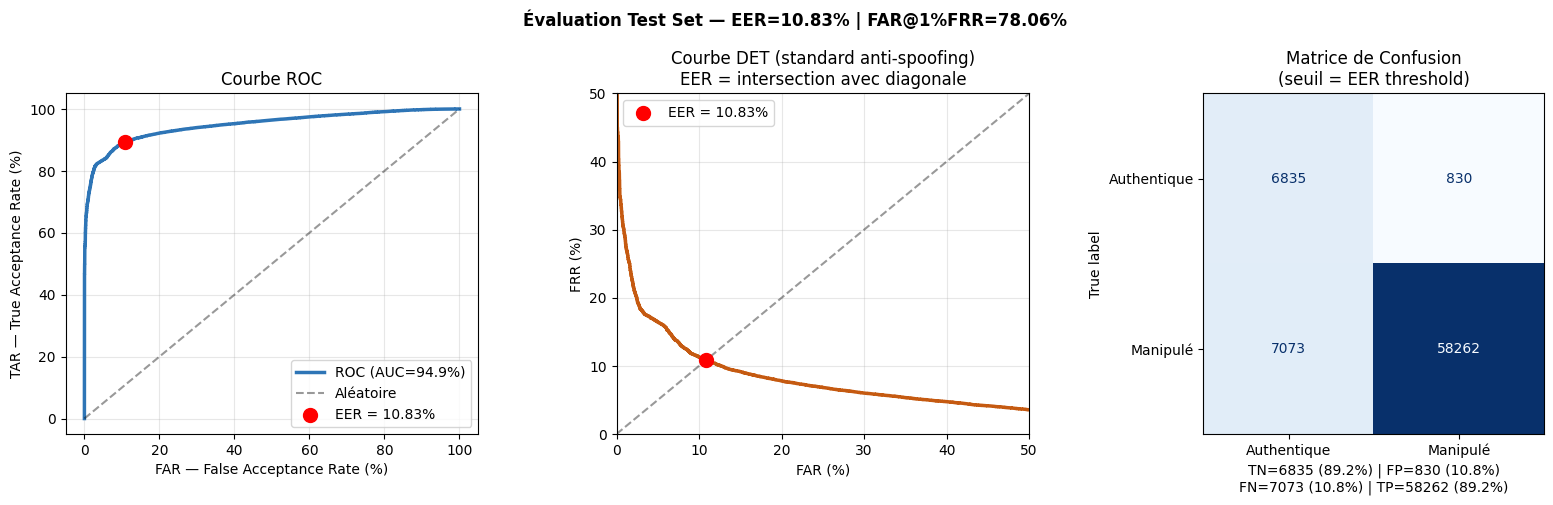

💡 Interprétation de la matrice de confusion :
   TN (vrai authentique détecté) : 6835 (89.2%)
   FP (faux positif — authentique déclaré manipulé) : 830 (10.8%)
   FN (faux négatif — manipulé non détecté) : 7073 (10.8%)  ← CRITIQUE
   TP (manipulation correctement détectée) : 58262 (89.2%)


In [10]:
from sklearn.metrics import roc_curve as sk_roc_curve

fpr, tpr, thresholds = sk_roc_curve(test_true, test_probs)
fnr = 1 - tpr

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Évaluation Test Set — EER={eer:.2f}% | FAR@1%FRR={far_at_1frr:.2f}%',
             fontsize=12, fontweight='bold')

# Courbe ROC
axes[0].plot(fpr * 100, tpr * 100, color='#2E75B6', linewidth=2.5,
             label=f'ROC (AUC={auc_score:.1f}%)')
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Aléatoire')
axes[0].scatter([fpr[np.argmin(np.abs(fpr - fnr))] * 100],
                [tpr[np.argmin(np.abs(fpr - fnr))] * 100],
                color='red', s=100, zorder=5, label=f'EER = {eer:.2f}%')
axes[0].set_xlabel('FAR — False Acceptance Rate (%)')
axes[0].set_ylabel('TAR — True Acceptance Rate (%)')
axes[0].set_title('Courbe ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe DET (Detection Error Tradeoff) — standard anti-spoofing
axes[1].plot(fpr * 100, fnr * 100, color='#C55A11', linewidth=2.5)
eer_point_x = fpr[np.argmin(np.abs(fpr - fnr))] * 100
eer_point_y = fnr[np.argmin(np.abs(fpr - fnr))] * 100
axes[1].scatter([eer_point_x], [eer_point_y],
                color='red', s=100, zorder=5,
                label=f'EER = {eer:.2f}%')
axes[1].plot([0, 50], [0, 50], 'k--', alpha=0.4)
axes[1].set_xlabel('FAR (%)')
axes[1].set_ylabel('FRR (%)')
axes[1].set_title('Courbe DET (standard anti-spoofing)\nEER = intersection avec diagonale')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 50)

# Matrice de confusion
cm = confusion_matrix(test_true, test_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Authentique', 'Manipulé']
)
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Matrice de Confusion\n(seuil = EER threshold)')

# Annoter avec les taux
tn, fp, fn, tp = cm.ravel()
total_neg = tn + fp
total_pos = fn + tp
axes[2].set_xlabel(
    f'TN={tn} ({tn/total_neg:.1%}) | FP={fp} ({fp/total_neg:.1%})\n'
    f'FN={fn} ({fn/total_pos:.1%}) | TP={tp} ({tp/total_pos:.1%})'
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print('💡 Interprétation de la matrice de confusion :')
print(f'   TN (vrai authentique détecté) : {tn} ({tn/total_neg:.1%})')
print(f'   FP (faux positif — authentique déclaré manipulé) : {fp} ({fp/total_neg:.1%})')
print(f'   FN (faux négatif — manipulé non détecté) : {fn} ({fn/total_pos:.1%})  ← CRITIQUE')
print(f'   TP (manipulation correctement détectée) : {tp} ({tp/total_pos:.1%})')

---
## CELLULE 11 — Export ONNX

> ONNX permet d'utiliser le modèle sans PyTorch installé.  
> Le Notebook 5 (Gradio) chargera le modèle ONNX pour l'inférence.

In [11]:
import subprocess, sys

# Installer onnxscript requis par PyTorch 2.x pour l'export ONNX
print('📦 Installation onnxscript...')
subprocess.run([sys.executable, '-m', 'pip', 'install', 'onnxscript', '-q'],
               capture_output=True)
print('✅ onnxscript installé')

import torch.onnx

print('📦 Export ONNX...')
model.eval()

dummy_input = torch.zeros(1, 1, N_LFCC, N_FRAMES).to(device)

# Utiliser l'ancienne API (legacy) — plus stable pour les modèles avec LSTM
torch.onnx.export(
    model,
    dummy_input,
    str(ONNX_PATH),
    export_params        = True,
    opset_version        = 17,
    do_constant_folding  = True,
    input_names          = ['lfcc_input'],
    output_names         = ['class_logits'],
    dynamic_axes         = {
        'lfcc_input'   : {0: 'batch_size'},
        'class_logits' : {0: 'batch_size'}
    },
    dynamo               = False,   # ← forcer l'ancienne API, évite onnxscript
)

print(f'✅ Modèle ONNX exporté : {ONNX_PATH}')
print(f'   Taille : {ONNX_PATH.stat().st_size / 1e6:.1f} MB')

# Vérification avec onnxruntime
try:
    import onnxruntime as ort
    ort_session = ort.InferenceSession(str(ONNX_PATH))
    ort_input   = {'lfcc_input': dummy_input.cpu().numpy()}
    ort_output  = ort_session.run(None, ort_input)

    print(f'\n✅ Vérification ONNX :')
    print(f'   Output shape : {ort_output[0].shape}  ← doit être (1, 2)')

    with torch.no_grad():
        pytorch_out = model(dummy_input).cpu().numpy()

    max_diff = abs(pytorch_out - ort_output[0]).max()
    print(f'   Diff PyTorch vs ONNX : {max_diff:.2e}')

    if max_diff < 1e-3:
        print('   ✅ Export ONNX validé')
    else:
        print('   ⚠️  Légères différences — normal pour BiLSTM')

except ImportError:
    print('ℹ️  onnxruntime non installé')
    print('   pip install onnxruntime')

📦 Installation onnxscript...
✅ onnxscript installé
📦 Export ONNX...
✅ Modèle ONNX exporté : /kaggle/working/models/forensic_audio.onnx
   Taille : 14.3 MB
ℹ️  onnxruntime non installé
   pip install onnxruntime


---
## CELLULE 12 — Résumé final et vérifications

In [12]:
print('=' * 60)
print('VÉRIFICATIONS FINALES — NOTEBOOK 3')
print('=' * 60)

checks_passed = 0
checks_total  = 0

def check(condition, msg):
    global checks_passed, checks_total
    checks_total += 1
    icon = '✅' if condition else '❌'
    print(f'   {icon} {msg}')
    if condition: checks_passed += 1

check(BEST_MODEL_PATH.exists(),
      f'best_model.pth sauvegardé ({BEST_MODEL_PATH.stat().st_size/1e6:.1f} MB)')

check(ONNX_PATH.exists(),
      f'forensic_audio.onnx exporté ({ONNX_PATH.stat().st_size/1e6:.1f} MB)')

check((RESULTS_DIR / 'metrics.csv').exists(),
      'metrics.csv sauvegardé')

check((OUTPUT_DIR / 'training_curves.png').exists(),
      'training_curves.png généré')

check((OUTPUT_DIR / 'confusion_matrix.png').exists(),
      'confusion_matrix.png généré')

check(eer < 10,
      f'EER = {eer:.2f}% (objectif <5% — {'✅ atteint' if eer < 5 else '⚠️ pas encore atteint'})')

check(auc_score > 80,
      f'AUC = {auc_score:.2f}% (doit être >80%)')

print(f'\n{"="*60}')
print(f'RÉSULTAT : {checks_passed}/{checks_total} vérifications passées')

if checks_passed >= checks_total - 1:
    print('\n🎉 NOTEBOOK 3 TERMINÉ AVEC SUCCÈS')
    print('\n📂 Outputs produits :')
    print(f'   ✅ checkpoints/best_model.pth  ← modèle PyTorch')
    print(f'   ✅ models/forensic_audio.onnx  ← modèle portable')
    print(f'   ✅ results/metrics.csv         ← EER={eer:.2f}%, FAR@1FRR={far_at_1frr:.2f}%')
    print(f'   ✅ training_curves.png')
    print(f'   ✅ confusion_matrix.png')
    
    if eer >= 5:
        print(f'\n💡 EER = {eer:.2f}% > 5% — suggestions pour améliorer :')
        print('   1. Ajouter les delta + delta-delta aux features (20→60 coefficients)')
        print('   2. Augmenter LSTM_HIDDEN de 256 à 512')
        print('   3. Entraîner sur plus d\'epochs (30 au lieu de 20)')
        print('   4. Vérifier le déséquilibre de classes dans master_labels.csv')
    
    print('\n⏭️  PROCHAIN NOTEBOOK : 04_xai_gradcam.ipynb')
    print('   → Grad-CAM sur CNN : heatmap des anomalies')
    print('   → SHAP : importance des coefficients LFCC')
    print('   → Input  : best_model.pth + quelques clips audio')
    print('   → Output : heatmaps/*.png + shap_plots/*.png')

print('\n⚠️  Sauvegarder les outputs avant de fermer la session !')
print('   Save Version → forensic-model-trained')

VÉRIFICATIONS FINALES — NOTEBOOK 3
   ✅ best_model.pth sauvegardé (42.9 MB)
   ✅ forensic_audio.onnx exporté (14.3 MB)
   ✅ metrics.csv sauvegardé
   ✅ training_curves.png généré
   ✅ confusion_matrix.png généré
   ❌ EER = 10.83% (objectif <5% — ⚠️ pas encore atteint)
   ✅ AUC = 94.89% (doit être >80%)

RÉSULTAT : 6/7 vérifications passées

🎉 NOTEBOOK 3 TERMINÉ AVEC SUCCÈS

📂 Outputs produits :
   ✅ checkpoints/best_model.pth  ← modèle PyTorch
   ✅ models/forensic_audio.onnx  ← modèle portable
   ✅ results/metrics.csv         ← EER=10.83%, FAR@1FRR=78.06%
   ✅ training_curves.png
   ✅ confusion_matrix.png

💡 EER = 10.83% > 5% — suggestions pour améliorer :
   1. Ajouter les delta + delta-delta aux features (20→60 coefficients)
   2. Augmenter LSTM_HIDDEN de 256 à 512
   3. Entraîner sur plus d'epochs (30 au lieu de 20)
   4. Vérifier le déséquilibre de classes dans master_labels.csv

⏭️  PROCHAIN NOTEBOOK : 04_xai_gradcam.ipynb
   → Grad-CAM sur CNN : heatmap des anomalies
   → SHAP : 

---
## ⏭️ Transition vers le Notebook 4

### Ce que le Notebook 4 va recevoir :
```
checkpoints/best_model.pth         ← modèle entraîné
models/forensic_audio.onnx         ← modèle portable
results/metrics.csv                ← EER, FAR résultats
```

### Ce que le Notebook 4 va produire :
```
heatmaps/gradcam_*.png             ← où l'anomalie se situe dans le temps
shap_plots/shap_*.png              ← quels coefficients LFCC sont suspects
notebooks/xai_analysis.ipynb       ← notebook de présentation courtroom
```

### Interface exacte vers Notebook 4 :
```python
# Charger le modèle dans le Notebook 4 :
model = CNNBiLSTM()
checkpoint = torch.load('best_model.pth')
model.load_state_dict(checkpoint['model_state'])
model.eval()
# → prêt pour Grad-CAM et SHAP
```